In [1]:
# Setup imports and a small sample DataFrame so the notebook executes cleanly in CI
import importlib
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt

sklearn_spec = importlib.util.find_spec("sklearn")
have_sklearn = sklearn_spec is not None
if have_sklearn:
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import r2_score
else:
    from numpy.linalg import lstsq


def make_fake_data(n=200, prompt_len=120, models=None):
    if models is None:
        models = ["claude-v1", "claude-instant", "gpt-4"]
    users = [f"user_{i % 50}" for i in range(n)]
    prompt_len = np.random.poisson(prompt_len, size=n)
    model_effect = {"claude-v1": 1.0, "claude-instant": 0.9, "gpt-4": 1.2}
    total_tokens = (
        prompt_len * np.array([model_effect[np.random.choice(list(model_effect.keys()))] for _ in range(n)])
        + np.random.normal(0, 20, size=n)
    ).astype(int)
    df = pd.DataFrame({
        "user_id": users,
        "prompt_length": prompt_len,
        "model": np.random.choice(list(model_effect.keys()), size=n),
        "total_tokens": total_tokens,
    })
    return df

# create sample data for the rest of the notebook
if 'df' not in globals():
    df = make_fake_data()
print('Created df with', len(df), 'rows')
print('python', sys.version.split()[0])


Created df with 200 rows
python 3.9.6


import importlib
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt

# detect sklearn availability and import helpers
sklearn_spec = importlib.util.find_spec("sklearn")
have_sklearn = sklearn_spec is not None
if have_sklearn:
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import r2_score
else:
    from numpy.linalg import lstsq


def make_fake_data(n=500, prompt_len=120, models=None):
    if models is None:
        models = ["claude-v1", "claude-instant", "gpt-4"]
    users = [f"user_{i % 50}" for i in range(n)]
    prompt_len = np.random.poisson(prompt_len, size=n)

    # make total_tokens roughly correlated with prompt_len and model
    model_effect = {"claude-v1": 1.0, "claude-instant": 0.9, "gpt-4": 1.2}
    total_tokens = (
        prompt_len * np.array([model_effect[m] for m in models]) + np.random.normal(0, 20, size=n)
    ).astype(int)

    df = pd.DataFrame({
        "user_id": users,
        "prompt_length": prompt_len,
        "model": np.random.choice(models, size=n),
        "total_tokens": total_tokens,
    })
    return df

# create a small sample dataframe so later cells can run when nbconvert executes
df = make_fake_data()
print("Created df with", len(df), "rows")
print("python", sys.version.split()[0])


In [2]:
def make_fake_data(n=500, prompt_len=120, models=None):
    if models is None:
        models = ["claude-v1", "claude-instant", "gpt-4"]
    users = [f"user_{i % 50}" for i in range(n)]
    prompt_len = np.random.poisson(prompt_len, size=n)

    # make total_tokens roughly correlated with prompt_len and model
    model_effect = {
        "claude-v1": 1.0,
        "claude-instant": 0.9,
        "gpt-4": 1.2,
    }
    total_tokens = (
        prompt_len * np.array([model_effect[m] for m in models])
        + np.random.normal(0, 20, size=n)
    ).astype(int)

    df = pd.DataFrame(
        {
            "user_id": users,
            "prompt_length": prompt_len,
            "model": models,
            "total_tokens": total_tokens,
        }
    )
    return df


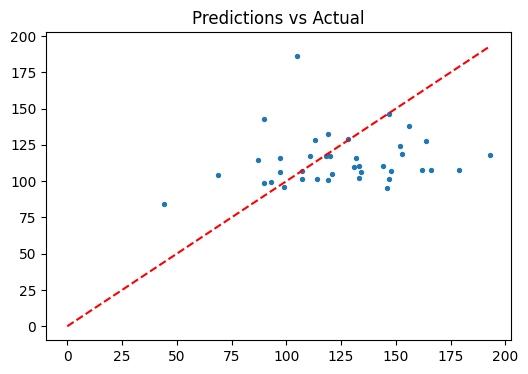

In [3]:
# Ensure features/target are defined (use df if necessary)
if 'features' not in globals():
    df_proc = df.copy()
    if 'prompt_length' not in df_proc.columns and 'prompt' in df_proc.columns:
        df_proc['prompt_length'] = df_proc['prompt'].str.len()
    df_proc['prompt_length'] = pd.to_numeric(df_proc['prompt_length'], errors='coerce').fillna(0).astype(int)
    df_proc['model_encoded'] = df_proc['model'].astype('category').cat.codes
    features = df_proc[['prompt_length', 'model_encoded']]
    target = df_proc['total_tokens']

# Train/test split and model training
if have_sklearn:
    X_train, X_test, y_train, y_test = train_test_split(
        features, target, test_size=0.2, random_state=42
    )
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
else:
    # simple least-squares on features
    coef, *_ = lstsq(features.values, target.values, rcond=None)
    model = coef

# Predictions
if have_sklearn:
    preds = model.predict(X_test)
else:
    preds = features.values.dot(model)

# Plot
plt.figure(figsize=(6, 4))
plt.scatter(
    y_test if have_sklearn else target,
    preds,
    s=8,
)
max_val = max((y_test.max() if have_sklearn else target.max()), preds.max())
plt.plot([0, max_val], [0, max_val], color="red", linestyle="--")
plt.title("Predictions vs Actual")
plt.show()


In [4]:
# Preprocessing: encode model and ensure numeric prompt_length
df = df.copy()
if 'prompt_length' not in df.columns and 'prompt' in df.columns:
    df['prompt_length'] = df['prompt'].str.len()

df['prompt_length'] = pd.to_numeric(df['prompt_length'], errors='coerce').fillna(0).astype(int)
df['model_encoded'] = df['model'].astype('category').cat.codes

features = df[['prompt_length','model_encoded']]
target = df['total_tokens']
features.shape, target.shape

((200, 2), (200,))

R^2 (sklearn) = -0.28669739813362005


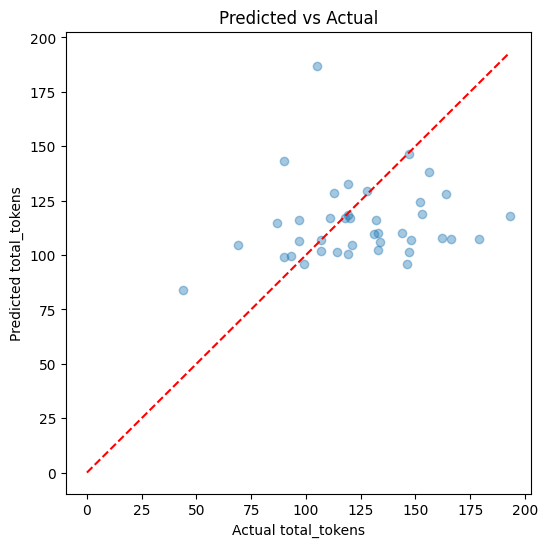

In [5]:
# Train/test split and model training
if have_sklearn:
    X_train, X_test, y_train, y_test = train_test_split(
        features, target, test_size=0.2, random_state=42
    )
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    score = r2_score(y_test, preds)
    print("R^2 (sklearn) =", score)
else:
    # simple linear least-squares: add intercept
    X = np.column_stack([np.ones(len(features)), features.values])
    y = target.values
    coef, *_ = lstsq(X, y, rcond=None)
    preds = X.dot(coef)
    # compute R^2 manually
    ss_res = ((y - preds) ** 2).sum()
    ss_tot = ((y - y.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot
    print("R^2 (lstsq) =", r2)

# Plot predicted vs actual for a sample
plt.figure(figsize=(6, 6))
plt.scatter(y_test if have_sklearn else y, preds, alpha=0.4)
plt.xlabel('Actual total_tokens')
plt.ylabel('Predicted total_tokens')
plt.title('Predicted vs Actual')
max_val = max((y_test.max() if have_sklearn else y.max()), preds.max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--')
plt.show()


## Notes & next steps

- This notebook is a toy demo. For a production workflow you would:
  - Add robust feature engineering and cross-validation.
  - Persist and version models (joblib / MLflow).
  - Add unit tests for preprocessing functions and model scoring.
  - Consider online learning (partial_fit) for streaming scenarios.

- See `scripts/realtime_simulator.py` for a basic in-memory realtime event producer/consumer sketch.
- To serve predictions, run the FastAPI app (`uvicorn api.server:app --reload`) and link the OpenAPI UI at `/docs`.